In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
client = pd.read_csv("/content/Client.csv")
record = pd.read_csv("/content/Record.csv")

In [4]:
client.shape
record.shape

(100000, 51)

In [5]:
client.head()
record.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005


In [6]:
client.columns
record.columns

Index(['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean',
       'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou',
       'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean',
       'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean',
       'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean',
       'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean',
       'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean',
       'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean',
       'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean',
       'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean',
       'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 'attempt_Mean',
       'complete_Mean', 'callfwdv_Mean', 'callwait_Mean', 'churn', 'months',
       'Customer_ID'],
      dtype='object')

In [7]:
client.info()
record.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 50 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   uniqsubs          100000 non-null  int64  
 1   actvsubs          100000 non-null  int64  
 2   new_cell          100000 non-null  object 
 3   crclscod          100000 non-null  object 
 4   asl_flag          100000 non-null  object 
 5   totcalls          100000 non-null  int64  
 6   totmou            100000 non-null  float64
 7   totrev            100000 non-null  float64
 8   adjrev            100000 non-null  float64
 9   adjmou            100000 non-null  float64
 10  adjqty            100000 non-null  int64  
 11  avgrev            100000 non-null  float64
 12  avgmou            100000 non-null  float64
 13  avgqty            100000 non-null  float64
 14  avg3mou           100000 non-null  int64  
 15  avg3qty           100000 non-null  int64  
 16  avg3rev           100

In [8]:
client.isnull().sum().sort_values(ascending=False)

,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


In [9]:
record.isnull().sum().sort_values(ascending=False)

,0
change_mou,891
change_rev,891
rev_Mean,357
totmrc_Mean,357
mou_Mean,357
da_Mean,357
ovrmou_Mean,357
vceovr_Mean,357
ovrrev_Mean,357
roam_Mean,357


In [11]:
"Customer_ID"

'Customer_ID'

In [12]:
df = pd.merge(client, record, on="Customer_ID")

In [13]:
df.shape
df.head()

,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58
3,1,1,Y,B,N,1502,3065.00000,2000.90,1941.81,3035.00,...,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60
4,1,1,Y,A,N,4485,14028.00000,2181.12,2166.48,13965.00,...,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57


In [14]:
df["churn"].value_counts()

,count
churn,
0,50438
1,49562


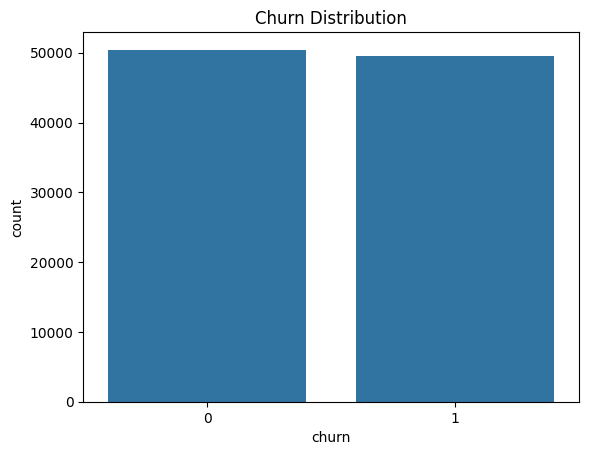

In [15]:
sns.countplot(x=df["churn"])
plt.title("Churn Distribution")
plt.show()

In [16]:
df = pd.merge(client, record, on="Customer_ID")

In [17]:
df.shape

(100000, 100)

In [18]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False).head(20)

,0
numbcars,49.366
dwllsize,38.308
HHstatin,37.923
ownrent,33.706
dwlltype,31.909
lor,30.190
income,25.436
adults,23.019
infobase,22.079
hnd_webcap,10.189


In [19]:
df.drop(columns=["numbcars"], inplace=True)

In [20]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
df.isnull().sum().sum()

np.int64(0)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [24]:
df.drop("Customer_ID", axis=1, inplace=True)

In [25]:
df.shape

(100000, 98)

In [26]:
df.dtypes.value_counts()

,count
float64,68
int64,30


In [27]:
corr = df.corr()["churn"].sort_values(ascending=False)

print(corr.head(15))
print(corr.tail(15))

churn          1.000000
eqpdays        0.112693
uniqsubs       0.039882
refurb_new     0.031788
vceovr_Mean    0.023617
ovrrev_Mean    0.023125
months         0.020991
actvsubs       0.019686
ovrmou_Mean    0.019142
marital        0.015132
area           0.013442
kid0_2         0.009741
roam_Mean      0.009188
change_rev     0.007863
ownrent        0.006813
Name: churn, dtype: float64
mou_peav_Mean   -0.047287
opk_vce_Mean    -0.047873
peak_vce_Mean   -0.048320
plcd_vce_Mean   -0.048321
attempt_Mean    -0.048533
hnd_webcap      -0.048884
mou_opkv_Mean   -0.048896
avg3mou         -0.049546
comp_vce_Mean   -0.051574
complete_Mean   -0.051740
mou_cvce_Mean   -0.052042
mou_Mean        -0.057326
totmrc_Mean     -0.068503
asl_flag        -0.069473
hnd_price       -0.102680
Name: churn, dtype: float64


In [28]:
df["churn"].mean()

np.float64(0.49562)

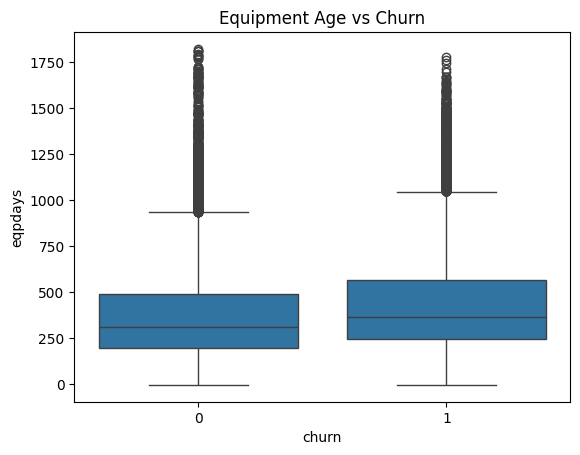

In [29]:
sns.boxplot(x="churn", y="eqpdays", data=df)
plt.title("Equipment Age vs Churn")
plt.show()

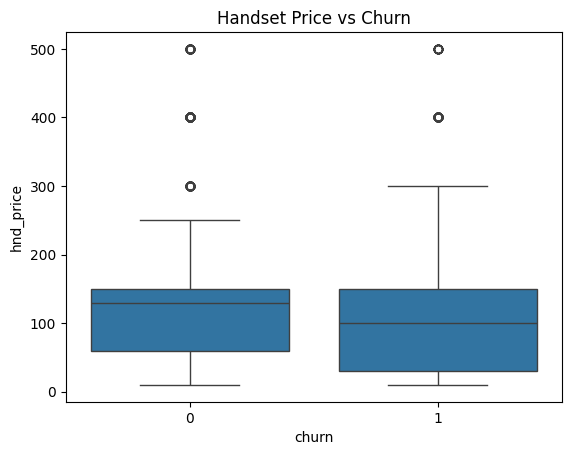

In [30]:
sns.boxplot(x="churn", y="hnd_price", data=df)
plt.title("Handset Price vs Churn")
plt.show()

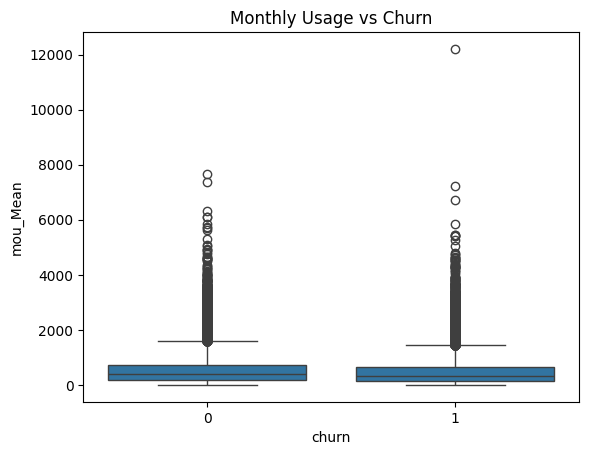

In [31]:
sns.boxplot(x="churn", y="mou_Mean", data=df)
plt.title("Monthly Usage vs Churn")
plt.show()

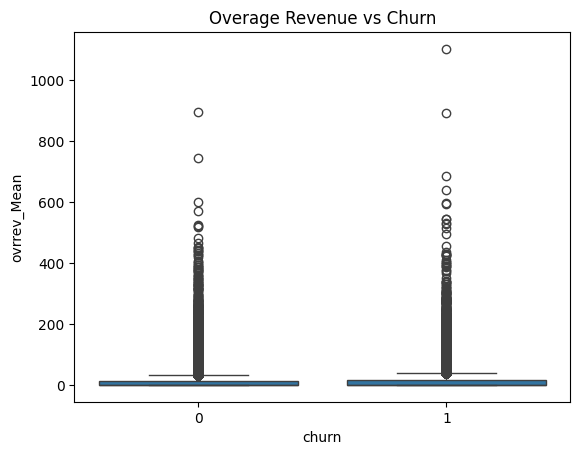

In [32]:
sns.boxplot(x="churn", y="ovrrev_Mean", data=df)
plt.title("Overage Revenue vs Churn")
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [34]:
X = df.drop("churn", axis=1)
y = df["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
y_pred = rf.predict(X_test)

In [37]:
accuracy_score(y_test, y_pred)

0.62395

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.63      0.63     10021
           1       0.63      0.62      0.62      9979

    accuracy                           0.62     20000
   macro avg       0.62      0.62      0.62     20000
weighted avg       0.62      0.62      0.62     20000



In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

       Feature  Importance
47     eqpdays    0.033909
57  change_mou    0.025928
96      months    0.024631
49    mou_Mean    0.021071
58  change_rev    0.020872
8       adjrev    0.020673
11      avgrev    0.020136
7       totrev    0.020092
13      avgqty    0.019975
12      avgmou    0.019725
5     totcalls    0.019098
48    rev_Mean    0.018989
6       totmou    0.018660
10      adjqty    0.018581
14     avg3mou    0.018288


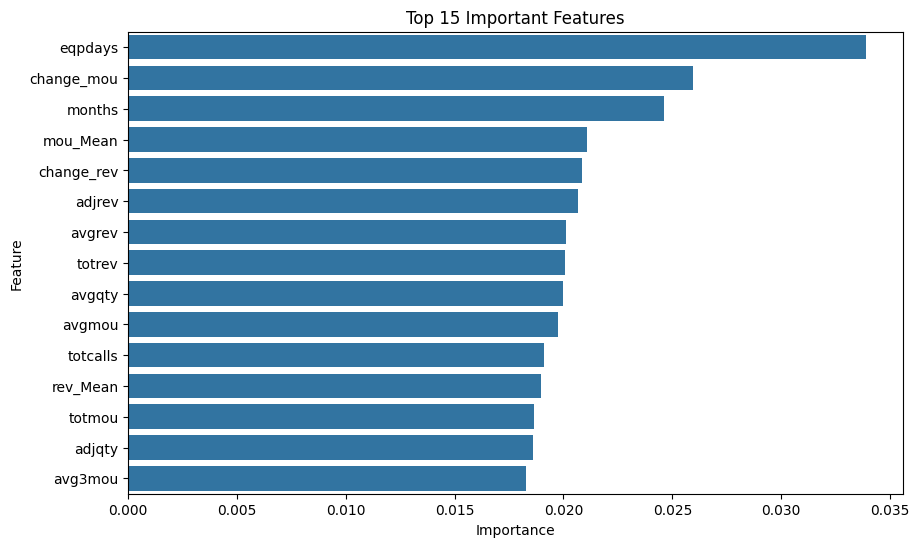

In [40]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top15
)

plt.title("Top 15 Important Features")

plt.show()

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [44]:
y_pred_lr = lr.predict(X_test_scaled)

In [45]:
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.5918
              precision    recall  f1-score   support

           0       0.59      0.60      0.59     10021
           1       0.59      0.59      0.59      9979

    accuracy                           0.59     20000
   macro avg       0.59      0.59      0.59     20000
weighted avg       0.59      0.59      0.59     20000



In [46]:
from sklearn.metrics import roc_auc_score

In [47]:
y_prob = rf.predict_proba(X_test)[:,1]

In [48]:
roc_auc_score(y_test, y_prob)

np.float64(0.6706967277725695)

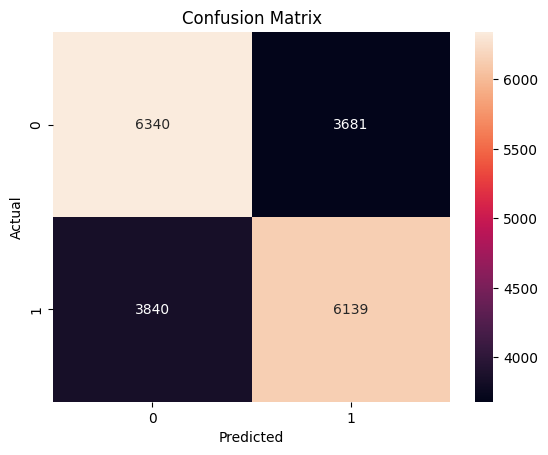

In [49]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [50]:
top10 = importance.head(10)
top10

,Feature,Importance
47,eqpdays,0.033909
57,change_mou,0.025928
96,months,0.024631
49,mou_Mean,0.021071
58,change_rev,0.020872
8,adjrev,0.020673
11,avgrev,0.020136
7,totrev,0.020092
13,avgqty,0.019975
12,avgmou,0.019725


In [51]:
df.groupby("churn")[[
    "eqpdays",
    "mou_Mean",
    "change_mou",
    "rev_Mean",
    "months"
]].mean()

,eqpdays,mou_Mean,change_mou,rev_Mean,months
churn,,,,,
0,363.280503,542.790083,-5.348090,59.194214,18.633074
1,421.089524,482.674631,-22.533162,58.161561,19.038457


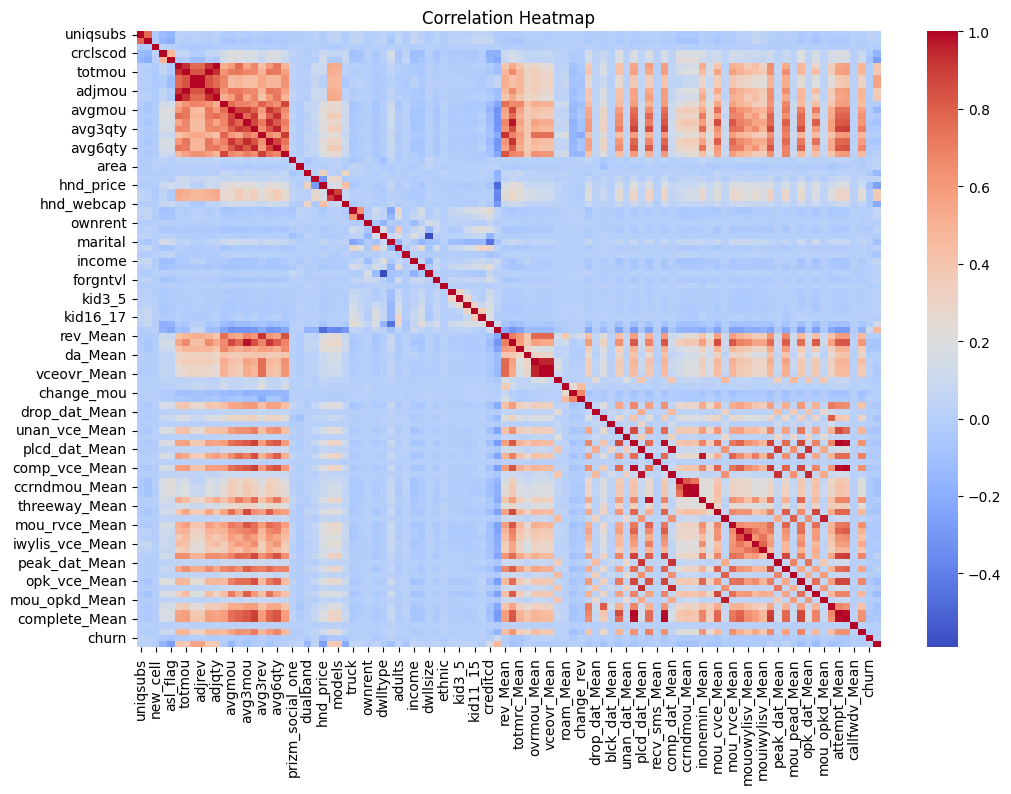

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

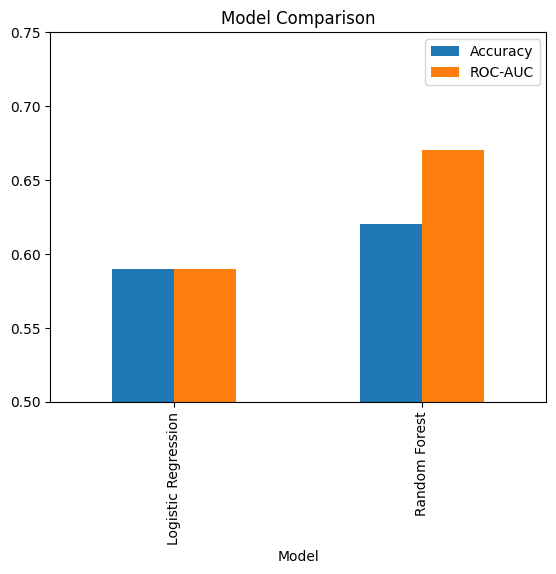

In [57]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.59, 0.62],
    "ROC-AUC": [0.59, 0.67]
})

import matplotlib.pyplot as plt

results.set_index("Model").plot(kind="bar")

plt.title("Model Comparison")
plt.ylim(0.5, 0.75)
plt.show()